# Homework: File conversion & Trace header fixing

This notebook prompts you to read a single **SEISAN** waveform file:

`2001-02-02-0303-55S.MVO___019`

and convert it into processed MiniSEED and SAC outputs, using ObsPy. Along the way you will practice:

* parsing information from filenames
* reading SEISAN waveforms
* editing Trace metadata
* tapering & filtering
* unit scaling using a sensitivity (or calibration) value
* changing the sampling rate
* writing MiniSEED and SAC

You may NOT use AI to help with this.

**Important: Make sure you read all the way to the bottom of these instructions before you start this exercise!**

## 0) Setup

Import read and UTCDateTime from obspy

Set a string variable called 'filename' that contains the path to the Seisan file, e.g.

```
filename = "/Users/thompsong/Developer/CompSciS26/week5/2001-02-02-0303-55S.MVO___019"
```

In [4]:
import obspy
import os
from obspy import read
from obspy import UTCDateTime
filename = "2001-02-02-0303-55S.MVO___019SEISAN"
print(filename)
print()
st = read(filename)
print(st)
print(os.listdir("."))


2001-02-02-0303-55S.MVO___019SEISAN

19 Trace(s) in Stream:
.MBRY.J.SBZ | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
.MBRY.J.SBN | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
.MBRY.J.SBE | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
.MBSS.J.S Z | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
.MBBY.J.SBZ | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
.MBBY.J.SBN | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
.MBBY.J.SBE | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
.MBGH.J.SBZ | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
.MBGH.J.SBN | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
.MBGH.J.SBE | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425


## 1) Parse the filename
Given the input filename like YYYY-MM-DD-hhmmssS.MVO__NUM, e.g. 2003-06-05-1845-15S.PVO___022 extract:

1.	Start time from the prefix formatted as YYYY-MM-DD-hhmm-ss and create a UTCDateTime from it.
<br/>Example: parse 2003-06-05-1845-15 into a UTCDateTime.

2.	The format code: the single letter after the time is S meaning SEISAN.

3.	The number of channels: the last 3 digits (e.g. 022) → integer number of channels.

Remember you can index and subset strings. 

Print a one-line summary like:

```Parsed starttime=2003-06-05T18:45:15Z, format=S, nchans=22```


In [9]:
filenames = filename.replace('./', '')
prefix = filenames[:19]
print(prefix)

year = prefix[0:4]
month = prefix[5:7]
day = prefix[8:10]
hour = prefix[11:13]
minute = prefix[13:15]
second = prefix[16:18]
print(year, month, day, hour, minute, second)

starttime = UTCDateTime(year + '-' + month + '-' + day + 'T' + hour + ':' + minute + ':' + second)
print(starttime)
fmt = filenames[18]
print(fmt)
nchans = int(filenames[26:29])
print(nchans)

print(f"Parsed starttime={starttime}, format={format}, nchans={nchans}")


2001-02-02-0303-55S
2001 02 02 03 03 55
2001-02-02T03:03:55.000000Z
S
19
Parsed starttime=2001-02-02T03:03:55.000000Z, format=<built-in function format>, nchans=19


## 2) Read the SEISAN file

Read the file into an ObsPy Stream.
* Verify that the number of traces in the stream matches the parsed channel count.
* If it does not match, print a warning and continue.

In [13]:
check_format = {"S": ".SEA"}
print("fmt =", repr(fmt))
print("prefix =", repr(prefix))
print("check_format keys =", check_format.keys())


newname = prefix + check_format[fmt]
print(newname)

old_file = filename
new_filename = './' + newname
if os.path.exists(new_filename):
    print("Already renamed:", new_filename)

elif os.path.exists(old_file):
    os.rename(old_file, new_filename)
    print("Renamed to:", new_filename)

else:
    print("ERROR: Neither old nor new file exists.")
    print("old_file:", old_file)
    print("new_filename:", new_filename)
    raise FileNotFoundError("Cannot continue — file missing.")

st_ = read(new_filename)
print(st_)

if len(st_) != nchans:
    print(f"Warning: expected {nchans} channels, but found {len(st)} channels in the file.")
else:
    print("Channel count matches expected value.")

fmt = 'S'
prefix = '2001-02-02-0303-55S'
check_format keys = dict_keys(['S'])
2001-02-02-0303-55S.SEA
Already renamed: ./2001-02-02-0303-55S.SEA
19 Trace(s) in Stream:
.MBRY.J.SBZ | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
.MBRY.J.SBN | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
.MBRY.J.SBE | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
.MBSS.J.S Z | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
.MBBY.J.SBZ | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
.MBBY.J.SBN | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
.MBBY.J.SBE | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
.MBGH.J.SBZ | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
.MBGH.J.SBN | 2001-02-02T03:03:55.040000Z - 2001-02-02T0

## 3) Fix the SEED codes

1) These all have a blank network code. Set network code to 'MV'.

2) The location code is bogus. Change it from 'J' to '00'.

3) The channel code is not SEED compliant. Make the following changes:
    * "PRS" -> "SDO" (barometer)
    * "SB" -> "BH"
    * "S " -> "SH"

In [25]:
for i in st_:
    i.stats.network = "MV"
    i.stats.location = "00"

# print(st_)

for r in st_:
    if r.stats.channel.startswith("SB"):
        r.stats.channel = "BH" + r.stats.channel[2:]
    elif r.stats.channel.startswith("PRS"):
        r.stats.channel = "SDO"
    elif r.stats.channel.startswith("S "):
        r.stats.channel = "SH" + r.stats.channel[2:]
print(st_)

19 Trace(s) in Stream:
MV.MBRY.00.BHZ | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
MV.MBRY.00.BHN | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
MV.MBRY.00.BHE | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
MV.MBSS.00.SHZ | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
MV.MBBY.00.BHZ | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
MV.MBBY.00.BHN | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
MV.MBBY.00.BHE | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
MV.MBGH.00.BHZ | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
MV.MBGH.00.BHN | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
MV.MBGH.00.BHE | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 

## 4) Preprocess each trace

Apply these steps in this order:

1.	Taper: 5% taper

2.	High-pass filter: 0.5 Hz, two-way (zero-phase)

3.	Scale to physical units using an overall sensitivity of 8,000,000 Counts per (m/s). The trace data are currently in Counts. Convert them to m/s.


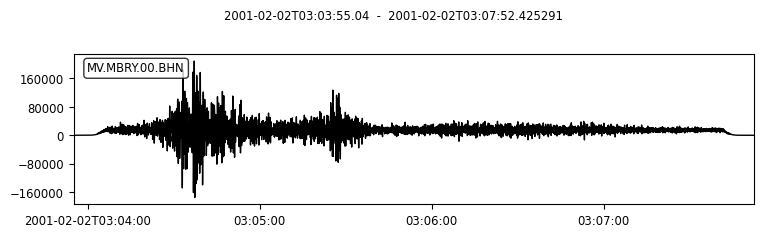

19 Trace(s) in Stream:
MV.MBRY.00.BHZ | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
MV.MBRY.00.BHN | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
MV.MBRY.00.BHE | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
MV.MBSS.00.SHZ | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
MV.MBBY.00.BHZ | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
MV.MBBY.00.BHN | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
MV.MBBY.00.BHE | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
MV.MBGH.00.BHZ | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
MV.MBGH.00.BHN | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 75.2 Hz, 17850 samples
MV.MBGH.00.BHE | 2001-02-02T03:03:55.040000Z - 2001-02-02T03:07:52.425291Z | 

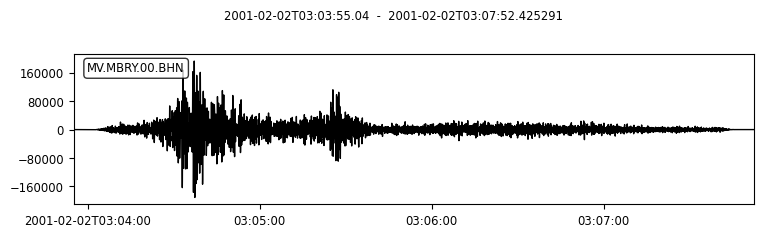

In [28]:
st_[1].plot();
taper = 0.05
hpf = 0.5
zero_phase = True
st_.taper(max_percentage=taper, type="hann")
st_.filter("highpass", freq=hpf, zerophase=zero_phase)
print(st_)
st_[1].plot();

## 5) Round the sampling rate
Change each trace sampling rate to the nearest integer (in samples/sec). 

In [29]:
for tr in st_:
    old_sampling_rate = tr.stats.sampling_rate
    new_sampling_rate = int(round(old_sampling_rate))
    print(f"Resampling from {old_sampling_rate} to {new_sampling_rate} Hz")
    tr.interpolate(new_sampling_rate)


Resampling from 75.19 to 75 Hz
Resampling from 75.19 to 75 Hz
Resampling from 75.19 to 75 Hz
Resampling from 75.19 to 75 Hz
Resampling from 75.19 to 75 Hz
Resampling from 75.19 to 75 Hz
Resampling from 75.19 to 75 Hz
Resampling from 75.19 to 75 Hz
Resampling from 75.19 to 75 Hz
Resampling from 75.19 to 75 Hz
Resampling from 75.19 to 75 Hz
Resampling from 75.19 to 75 Hz
Resampling from 75.19 to 75 Hz
Resampling from 75.19 to 75 Hz
Resampling from 75.19 to 75 Hz
Resampling from 75.19 to 75 Hz
Resampling from 75.19 to 75 Hz
Resampling from 75.19 to 75 Hz
Resampling from 75.19 to 75 Hz


## 6) Force the start time

Set the start time for every trace to:<br/>
```UTCDateTime(‘2001-02-02T03:00:00’)```


In [31]:
t0 = UTCDateTime('2001-02-02T03:00:00')

for tr in st_:
    tr.trim(starttime=t0, pad=True, fill_value=0)
print(st_)

19 Trace(s) in Stream:
MV.MBRY.00.BHZ | 2001-02-02T03:00:00.000000Z - 2001-02-02T03:07:52.413333Z | 75.0 Hz, 35432 samples
MV.MBRY.00.BHN | 2001-02-02T03:00:00.000000Z - 2001-02-02T03:07:52.413333Z | 75.0 Hz, 35432 samples
MV.MBRY.00.BHE | 2001-02-02T03:00:00.000000Z - 2001-02-02T03:07:52.413333Z | 75.0 Hz, 35432 samples
MV.MBSS.00.SHZ | 2001-02-02T03:00:00.000000Z - 2001-02-02T03:07:52.413333Z | 75.0 Hz, 35432 samples
MV.MBBY.00.BHZ | 2001-02-02T03:00:00.000000Z - 2001-02-02T03:07:52.413333Z | 75.0 Hz, 35432 samples
MV.MBBY.00.BHN | 2001-02-02T03:00:00.000000Z - 2001-02-02T03:07:52.413333Z | 75.0 Hz, 35432 samples
MV.MBBY.00.BHE | 2001-02-02T03:00:00.000000Z - 2001-02-02T03:07:52.413333Z | 75.0 Hz, 35432 samples
MV.MBGH.00.BHZ | 2001-02-02T03:00:00.000000Z - 2001-02-02T03:07:52.413333Z | 75.0 Hz, 35432 samples
MV.MBGH.00.BHN | 2001-02-02T03:00:00.000000Z - 2001-02-02T03:07:52.413333Z | 75.0 Hz, 35432 samples
MV.MBGH.00.BHE | 2001-02-02T03:00:00.000000Z - 2001-02-02T03:07:52.413333Z | 

## 7A) Write MiniSEED

1. Output filename should match the input naming style, but replace the S with M. But remember that the start time has changed.

2. Write stream as MiniSEED.

3. Re-read the MiniSEED file and plot it.



In [41]:
for tr in st_:
    t = tr.stats.starttime

    year = f"{t.year:04d}"
    month = f"{t.month:02d}"
    day = f"{t.day:02d}"   
    hour = f"{t.hour:02d}"
    minute = f"{t.minute:02d}"
    second = f"{t.second:02d}"

    new_prefix = f"{year}-{month}-{day}T{hour}:{minute}:{second}"
    # print("new_prefix:", new_prefix)

    fmt = "M"
    file = filename.replace('./', '')
    network = file[20:23]
    nchans = int(file[26:29])

    newname1 = f"{prefix}{fmt}{network}_{nchans:03d}"

    print("newname1:", newname1)

    tr.write(newname1, format="MSEED")

newname1: 2001-02-02-0303-55SMMVO_019
newname1: 2001-02-02-0303-55SMMVO_019
newname1: 2001-02-02-0303-55SMMVO_019
newname1: 2001-02-02-0303-55SMMVO_019
newname1: 2001-02-02-0303-55SMMVO_019
newname1: 2001-02-02-0303-55SMMVO_019
newname1: 2001-02-02-0303-55SMMVO_019
newname1: 2001-02-02-0303-55SMMVO_019
newname1: 2001-02-02-0303-55SMMVO_019
newname1: 2001-02-02-0303-55SMMVO_019
newname1: 2001-02-02-0303-55SMMVO_019
newname1: 2001-02-02-0303-55SMMVO_019
newname1: 2001-02-02-0303-55SMMVO_019
newname1: 2001-02-02-0303-55SMMVO_019
newname1: 2001-02-02-0303-55SMMVO_019
newname1: 2001-02-02-0303-55SMMVO_019
newname1: 2001-02-02-0303-55SMMVO_019
newname1: 2001-02-02-0303-55SMMVO_019
newname1: 2001-02-02-0303-55SMMVO_019


## 7B) Write SAC

1. Write SAC files (one per trace).

2. Put them in a folder like SAC/.

3. Filenames should include NET.STA.LOC.CHA and optionally start time.

4. Re-read the SAC files and plot them.


In [52]:
os.makedirs("SAC", exist_ok=True)

for r in st_:
    net = r.stats.network
    sta = r.stats.station
    loc = r.stats.location
    cha = r.stats.channel

    t = r.stats.starttime
    timestring = t.strftime("%Y%m%dT%H%M%S")

    sac_name = f"{net}.{sta}.{loc}.{cha}.{timestring}.SAC"
    outfile = os.path.join("SAC", sac_name)

    r.write(outfile, format="SAC")
    print(f"Wrote SAC file: {outfile}")

Wrote SAC file: SAC\MV.MBRY.00.BHZ.20010202T030000.SAC
Wrote SAC file: SAC\MV.MBRY.00.BHN.20010202T030000.SAC
Wrote SAC file: SAC\MV.MBRY.00.BHE.20010202T030000.SAC
Wrote SAC file: SAC\MV.MBSS.00.SHZ.20010202T030000.SAC
Wrote SAC file: SAC\MV.MBBY.00.BHZ.20010202T030000.SAC
Wrote SAC file: SAC\MV.MBBY.00.BHN.20010202T030000.SAC
Wrote SAC file: SAC\MV.MBBY.00.BHE.20010202T030000.SAC
Wrote SAC file: SAC\MV.MBGH.00.BHZ.20010202T030000.SAC
Wrote SAC file: SAC\MV.MBGH.00.BHN.20010202T030000.SAC
Wrote SAC file: SAC\MV.MBGH.00.BHE.20010202T030000.SAC
Wrote SAC file: SAC\MV.MBWH.00.SHZ.20010202T030000.SAC
Wrote SAC file: SAC\MV.MBGB.00.BHZ.20010202T030000.SAC
Wrote SAC file: SAC\MV.MBGB.00.BHN.20010202T030000.SAC
Wrote SAC file: SAC\MV.MBGB.00.BHE.20010202T030000.SAC
Wrote SAC file: SAC\MV.MBMH.00.SHZ.20010202T030000.SAC
Wrote SAC file: SAC\MV.MBMH.00.SHN.20010202T030000.SAC
Wrote SAC file: SAC\MV.MBMH.00.SHE.20010202T030000.SAC
Wrote SAC file: SAC\MV.MBLG.00.SHZ.20010202T030000.SAC
Wrote SAC 

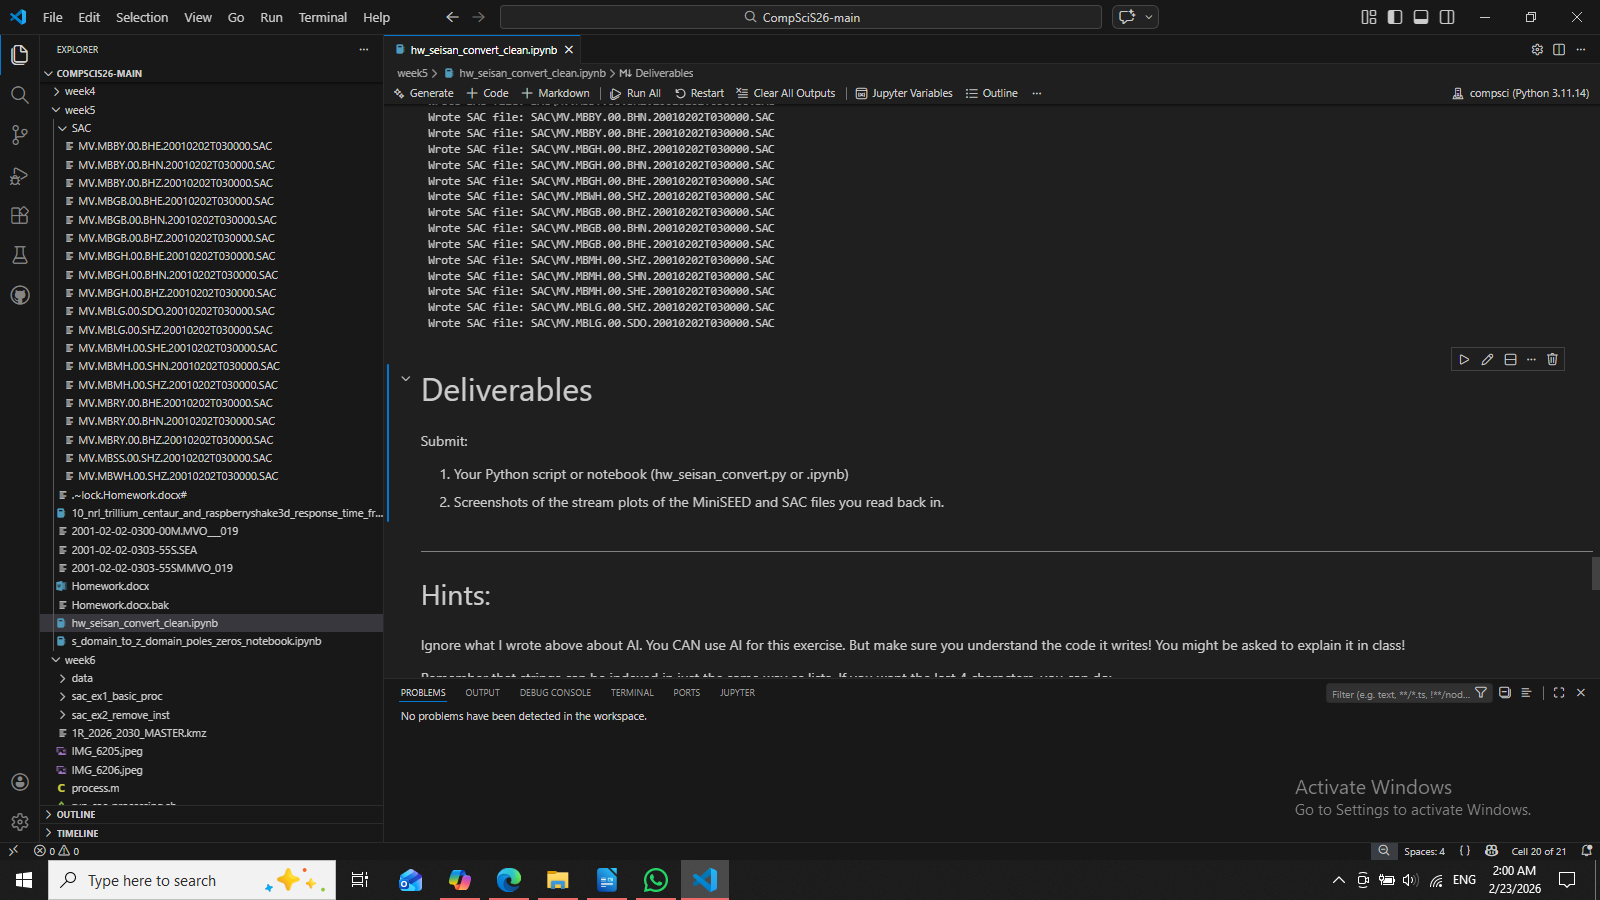

# Deliverables

Submit:

1.	Your Python script or notebook (hw_seisan_convert.py or .ipynb)

2.	Screenshots of the stream plots of the MiniSEED and SAC files you read back in.


---

## Hints:

Ignore what I wrote above about AI. You CAN use AI for this exercise. But make sure you understand the code it writes! You might be asked to explain it in class!

Remember that strings can be indexed in just the same way as lists. If you want the last 4 characters, you can do:

```
my_str = “my_filename.123”
last_4 = my_str[-4:]
```

Or you can split on “_” using:
```
my_list = my_str.split(“_”)
```

You can round a float(ing point variable) to the nearest integer with the round() function:

```
a = 75.19
b = round(a)
print(b) # b=75
```

You can build a UTCDateTime object from a string by specifying the string format, e.g.:

```
import obspy
filename = “2022-05-08-1715-05M.PVO__006”
filetime = obspy.UTCDateTime.strptime(filename, “%Y-%m-%d-%H%M-%S”)
```

Read a waveform file like this:

```
import obspy
st = obspy.read(filename) # read outputs an ObsPy Stream object
```

Remember you can loop over Trace objects in a Stream object like this:

```
for tr in st:
    # THIS IS A COMMENT do something to tr
```

You can taper and filter traces with:

```
tr.taper()
tr.filter()
```

A Trace object has a stats attribute, and a data attribute.

```
tr.data # this is a numpy array – the actual sequence of sample values in the timeseries
tr.stats # this is a dictionary with attributes such as:
    #	sampling_rate
    #	network
    #	station
    #	location
    # 	channel
```

To scale a numpy array called ‘a’ by a factor of 5 you can do:

$$f = 5$$
$$a = a * f$$

Remember that tr.data is a numpy array.
But also see what happens if you just try to multiple tr directly:

```tr = tr * 5```

You can write a Stream object to a file using:
st.write(‘/path/to/filename.ext’, format=’<format>’)
Where <format> is ‘mseed’, or ‘sac’, or ‘seisan’, or some other format ObsPy supports.
You can also write a Trace object to a file in exactly the same way.




